In [1]:
# =========================
# PART 3 - LANGUAGE TASK
# Sarcasm Detection in News Headlines
# Using RNN, LSTM, and Word2Vec
# =========================

# =========================
# 1. INSTALL REQUIRED LIBRARIES
# =========================

!pip install contractions gensim nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.1 MB/s eta 0:00:00


In [6]:
# # =========================
# # 2. IMPORT LIBRARIES
# # =========================

# import re
# import time
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import contractions

# import nltk
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("omw-1.4")

# from nltk.corpus import stopwords
# from nltk.stem import WordNetLemmatizer

# import tensorflow as tf
# from tensorflow.keras.preprocessing.text import Tokenizer
# from tensorflow.keras.preprocessing.sequence import pad_sequences
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from tensorflow.keras.optimizers import Adam

# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import contractions

import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout,
    Bidirectional, LayerNormalization, GlobalAveragePooling1D,
    Conv1D, MaxPooling1D, Input, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [7]:
# =========================
# 3. MOUNT GOOGLE DRIVE
# =========================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# =========================
# 4. LOAD DATASET
# =========================

# Change this path according to your actual CSV location in Google Drive.
DATASET_PATH = "/content/drive/MyDrive/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv"

df = pd.read_csv(DATASET_PATH)

print(df.head())
print(df.shape)
print(df.columns)

                                            headline  is_sarcastic
0  thirtysomething scientists unveil doomsday clo...             1
1  dem rep. totally nails why congress is falling...             0
2  eat your veggies: 9 deliciously different recipes             0
3  inclement weather prevents liar from getting t...             1
4  mother comes pretty close to using word 'strea...             1
(28619, 2)
Index(['headline', 'is_sarcastic'], dtype='object')


Missing Values:
headline        0
is_sarcastic    0
dtype: int64

Class Distribution:
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


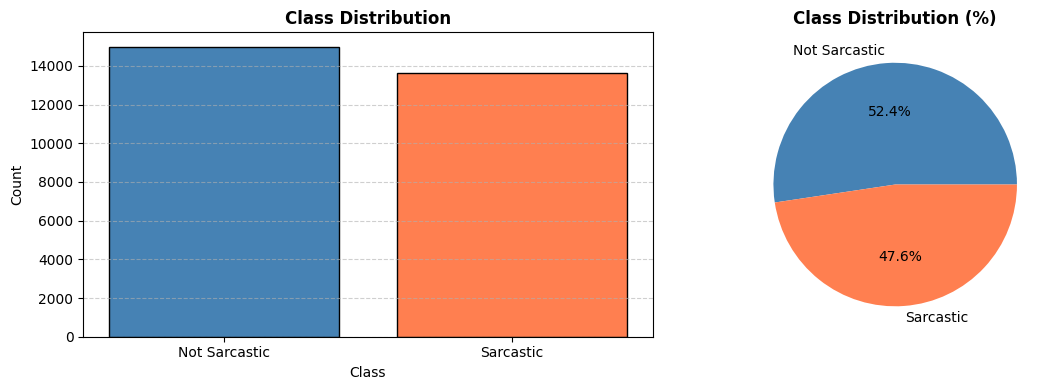

In [9]:
# # =========================
# # 5. BASIC DATASET CHECK
# # =========================

# print("Missing Values:")
# print(df.isnull().sum())

# print("\nClass Distribution:")
# print(df["is_sarcastic"].value_counts())

# plt.figure(figsize=(6,4))
# df["is_sarcastic"].value_counts().plot(kind="bar")
# plt.title("Class Distribution")
# plt.xlabel("Class")
# plt.ylabel("Count")
# plt.xticks([0, 1], ["Not Sarcastic", "Sarcastic"], rotation=0)
# plt.show()
print("Missing Values:")
print(df.isnull().sum())

print("\nClass Distribution:")
print(df["is_sarcastic"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Not Sarcastic", "Sarcastic"],
            df["is_sarcastic"].value_counts().values,
            color=["steelblue", "coral"], edgecolor="black")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

df["is_sarcastic"].value_counts().plot(
    kind="pie",
    labels=["Not Sarcastic", "Sarcastic"],
    autopct="%1.1f%%",
    colors=["steelblue", "coral"],
    ax=axes[1]
)
axes[1].set_title("Class Distribution (%)", fontweight="bold")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [10]:
# # =========================
# # 6. TEXT PREPROCESSING
# # =========================

# stop_words = set(stopwords.words("english"))
# lemmatizer = WordNetLemmatizer()

# def clean_text(text):
#     text = str(text).lower()
#     text = contractions.fix(text)

#     text = re.sub(r"http\S+|www\S+", "", text)
#     text = re.sub(r"@\w+", "", text)
#     text = re.sub(r"#\w+", "", text)
#     text = re.sub(r"[^a-zA-Z\s]", "", text)
#     text = re.sub(r"\s+", " ", text).strip()

#     words = text.split()
#     words = [word for word in words if word not in stop_words]
#     words = [lemmatizer.lemmatize(word) for word in words]

#     return " ".join(words)

# df["clean_headline"] = df["headline"].apply(clean_text)

# df[["headline", "clean_headline", "is_sarcastic"]].head()
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = contractions.fix(text)

    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["clean_headline"] = df["headline"].apply(clean_text)

df[["headline", "clean_headline", "is_sarcastic"]].head()

,headline,clean_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1


Average Length: 7.074880324260107
90th Percentile Length: 10.0


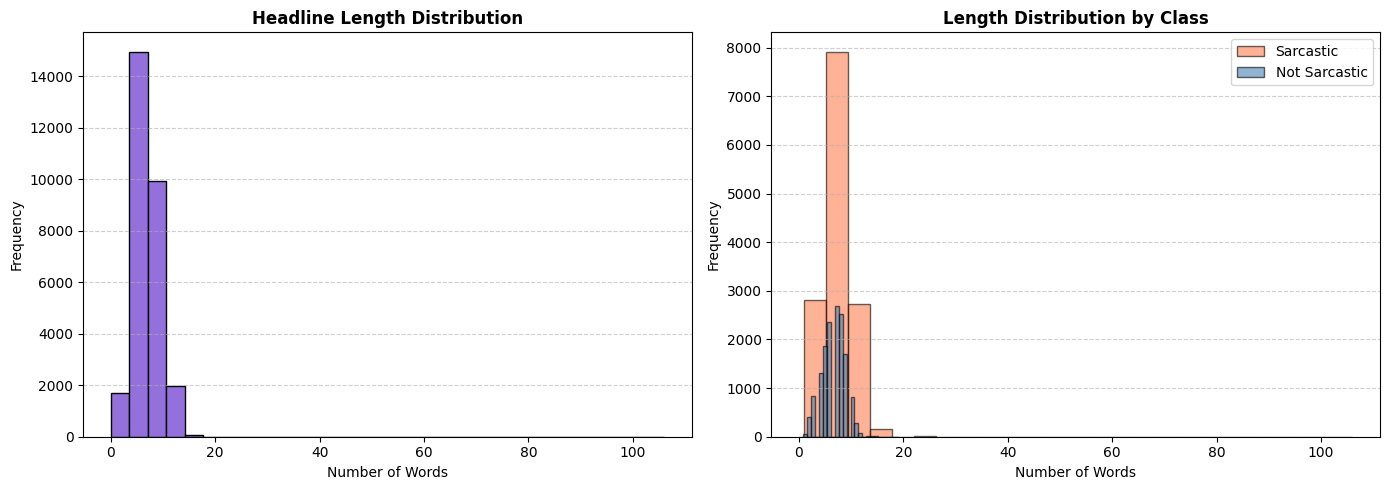

In [11]:
# =========================
# 7. HEADLINE LENGTH ANALYSIS
# =========================


df["text_length"] = df["clean_headline"].apply(lambda x: len(x.split()))

print("Average Length:", df["text_length"].mean())
print("90th Percentile Length:", np.percentile(df["text_length"], 90))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["text_length"], bins=30, color="mediumpurple", edgecolor="black")
axes[0].set_title("Headline Length Distribution", fontweight="bold")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

sarcastic_len = df[df["is_sarcastic"] == 1]["text_length"]
not_sarcastic_len = df[df["is_sarcastic"] == 0]["text_length"]
axes[1].hist(sarcastic_len, bins=25, alpha=0.6, label="Sarcastic", color="coral", edgecolor="black")
axes[1].hist(not_sarcastic_len, bins=25, alpha=0.6, label="Not Sarcastic", color="steelblue", edgecolor="black")
axes[1].set_title("Length Distribution by Class", fontweight="bold")
axes[1].set_xlabel("Number of Words")
axes[1].set_ylabel("Frequency")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [12]:
# =========================
# 8. TRAIN TEST SPLIT
# =========================

X = df["clean_headline"]
y = df["is_sarcastic"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training Samples:", len(X_train_text))
print("Testing Samples:", len(X_test_text))


Training Samples: 22895
Testing Samples: 5724


In [13]:
VOCAB_SIZE = 10000
MAX_LEN = 14
EMBEDDING_DIM = 128

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

word_index = tokenizer.word_index

print("Vocabulary Size:", len(word_index))
print("Training Shape:", X_train_pad.shape)
print("Testing Shape:", X_test_pad.shape)

Vocabulary Size: 22523
Training Shape: (22895, 14)
Testing Shape: (5724, 14)


In [14]:
# =========================
# 10. CALLBACKS
# =========================

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [15]:
# =========================
# 11. MODEL 1 - STACKED GRU WITH LAYER NORMALIZATION
# Uses GRU instead of SimpleRNN, stacked layers,
# LayerNormalization, and L2 regularization
# =========================

model_rnn = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    # First GRU layer - returns sequences for stacking
    GRU(96, return_sequences=True, kernel_regularizer=l2(0.001)),
    LayerNormalization(),
    Dropout(0.35),

    # Second GRU layer
    GRU(48, kernel_regularizer=l2(0.001)),
    LayerNormalization(),
    Dropout(0.3),

    # Classifier head
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer=RMSprop(learning_rate=0.0008),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# =========================
# 12. TRAIN MODEL 1 - STACKED GRU
# =========================

start_time = time.time()

history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

rnn_time = time.time() - start_time
print("Stacked GRU Training Time:", rnn_time)

Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 29s 62ms/step - accuracy: 0.6491 - loss: 0.8231 - val_accuracy: 0.7707 - val_loss: 0.6093 - learning_rate: 8.0000e-04
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8240 - loss: 0.5103 - val_accuracy: 0.7919 - val_loss: 0.5257 - learning_rate: 8.0000e-04
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 23s 79ms/step - accuracy: 0.8669 - loss: 0.3969 - val_accuracy: 0.7995 - val_loss: 0.5032 - learning_rate: 8.0000e-04
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - accuracy: 0.8959 - loss: 0.3216 - val_accuracy: 0.7949 - val_loss: 0.5219 - learning_rate: 8.0000e-04
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9221 - loss: 0.2586
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00023999999393709004.
287/287 ━━━━━━━━━━━━━━━━━━━━ 28s 97ms/step - accuracy: 0.9176 - loss: 0.2672 - val_accuracy: 0.7888 - val_loss: 0.5778 - learning_rate: 8.0000e-04
Epoch 6/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - 

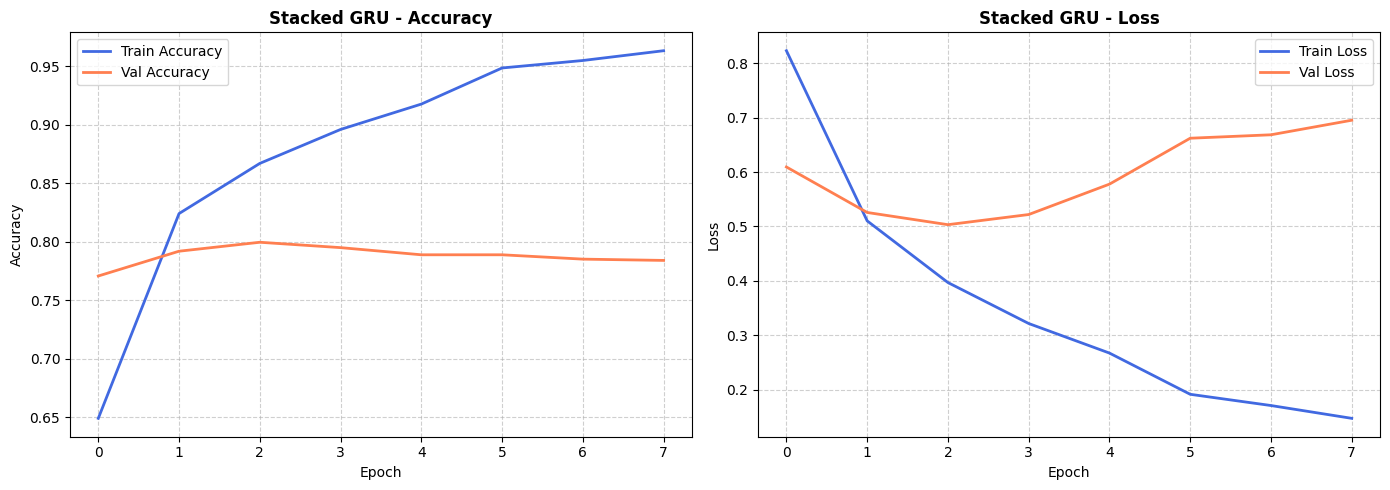

In [17]:
# =========================
# 13. MODEL 1 GRAPHS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_rnn.history["accuracy"], label="Train Accuracy", color="royalblue", linewidth=2)
axes[0].plot(history_rnn.history["val_accuracy"], label="Val Accuracy", color="coral", linewidth=2)
axes[0].set_title("Stacked GRU - Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history_rnn.history["loss"], label="Train Loss", color="royalblue", linewidth=2)
axes[1].plot(history_rnn.history["val_loss"], label="Val Loss", color="coral", linewidth=2)
axes[1].set_title("Stacked GRU - Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.7930 - loss: 0.5036
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
Stacked GRU Test Accuracy: 0.7929769158363342
               precision    recall  f1-score   support

Not Sarcastic       0.83      0.76      0.79      2997
    Sarcastic       0.76      0.83      0.79      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.80      0.79      0.79      5724



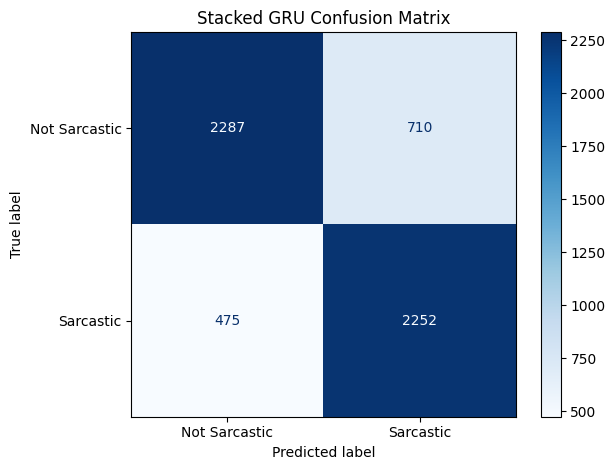

In [18]:
# =========================
# 14. EVALUATE MODEL 1
# =========================
rnn_loss, rnn_acc = model_rnn.evaluate(X_test_pad, y_test)

rnn_pred_prob = model_rnn.predict(X_test_pad)
rnn_pred = (rnn_pred_prob > 0.5).astype(int).flatten()

print("Stacked GRU Test Accuracy:", rnn_acc)
print(classification_report(y_test, rnn_pred,
      target_names=["Not Sarcastic", "Sarcastic"], zero_division=0))

cm = confusion_matrix(y_test, rnn_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Sarcastic", "Sarcastic"])
disp.plot(cmap="Blues")
plt.title("Stacked GRU Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
# =========================
# 15. MODEL 2 - CNN + BIDIRECTIONAL LSTM HYBRID
# Combines Conv1D feature extraction with BiLSTM
# for richer sequential understanding
# =========================

model_lstm = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    # CNN feature extraction block
    Conv1D(filters=128, kernel_size=3, activation="relu", padding="same"),
    MaxPooling1D(pool_size=2),
    Dropout(0.25),

    # Bidirectional LSTM block
    Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))),
    Dropout(0.35),

    Bidirectional(LSTM(32, kernel_regularizer=l2(0.001))),
    LayerNormalization(),
    Dropout(0.3),

    # Classifier head
    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.0005, beta_1=0.9, beta_2=0.999),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:

# =========================
# 16. TRAIN MODEL 2 - CNN + BiLSTM HYBRID
# =========================

start_time = time.time()

history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

lstm_time = time.time() - start_time
print("CNN + BiLSTM Training Time:", lstm_time)

Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 27s 61ms/step - accuracy: 0.6938 - loss: 0.8673 - val_accuracy: 0.7829 - val_loss: 0.6233 - learning_rate: 5.0000e-04
Epoch 2/15
286/287 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8749 - loss: 0.4588
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
287/287 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.8676 - loss: 0.4496 - val_accuracy: 0.7879 - val_loss: 0.5840 - learning_rate: 5.0000e-04
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 0.9541 - loss: 0.2413 - val_accuracy: 0.8006 - val_loss: 0.6634 - learning_rate: 1.5000e-04
Epoch 4/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9774 - loss: 0.1745
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.500000213738531e-05.
287/287 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.9770 - loss: 0.1704 - val_accuracy: 0.8000 - val_loss: 0.7782 - learning_rate: 1.5000e-04
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 23s 69ms/step - accuracy

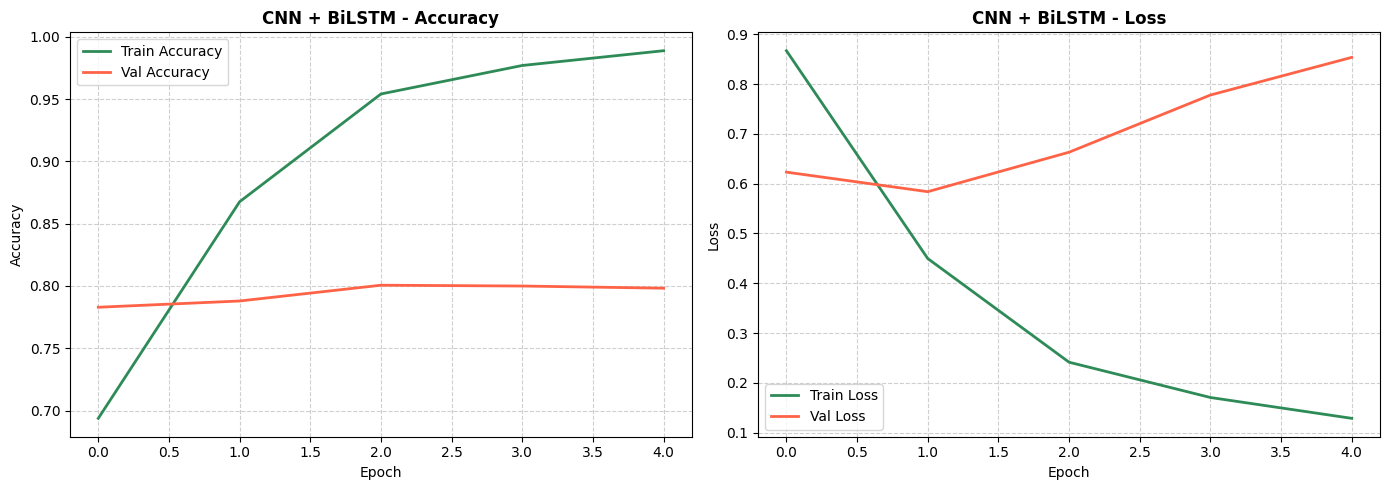

In [21]:
# =========================
# 17. MODEL 2 GRAPHS
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_lstm.history["accuracy"], label="Train Accuracy", color="seagreen", linewidth=2)
axes[0].plot(history_lstm.history["val_accuracy"], label="Val Accuracy", color="tomato", linewidth=2)
axes[0].set_title("CNN + BiLSTM - Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history_lstm.history["loss"], label="Train Loss", color="seagreen", linewidth=2)
axes[1].plot(history_lstm.history["val_loss"], label="Val Loss", color="tomato", linewidth=2)
axes[1].set_title("CNN + BiLSTM - Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7748 - loss: 0.6299
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step
CNN + BiLSTM Test Accuracy: 0.7748078107833862
               precision    recall  f1-score   support

Not Sarcastic       0.73      0.89      0.81      2997
    Sarcastic       0.84      0.65      0.73      2727

     accuracy                           0.77      5724
    macro avg       0.79      0.77      0.77      5724
 weighted avg       0.79      0.77      0.77      5724



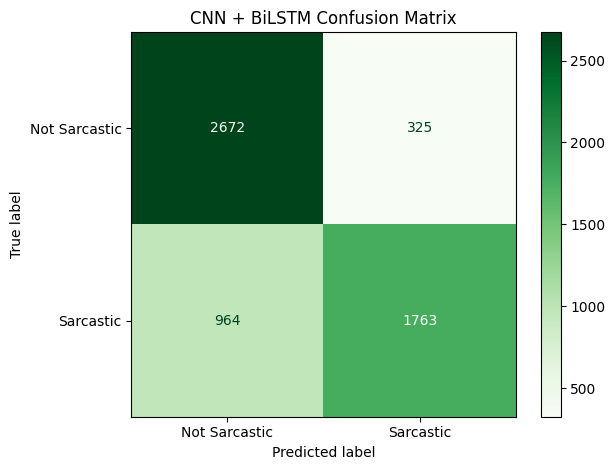

In [22]:
# =========================
# 18. EVALUATE MODEL 2
# =========================
lstm_loss, lstm_acc = model_lstm.evaluate(X_test_pad, y_test)

lstm_pred_prob = model_lstm.predict(X_test_pad)
lstm_pred = (lstm_pred_prob > 0.5).astype(int).flatten()

print("CNN + BiLSTM Test Accuracy:", lstm_acc)
print(classification_report(y_test, lstm_pred,
      target_names=["Not Sarcastic", "Sarcastic"], zero_division=0))

cm = confusion_matrix(y_test, lstm_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Sarcastic", "Sarcastic"])
disp.plot(cmap="Greens")
plt.title("CNN + BiLSTM Confusion Matrix")
plt.tight_layout()
plt.show()

In [23]:
# =========================
# 19. LOAD PRETRAINED WORD2VEC
# =========================

import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")

WORD2VEC_DIM = 300

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [24]:
# =========================
# 20. CREATE WORD2VEC EMBEDDING MATRIX
# =========================

embedding_matrix = np.zeros((VOCAB_SIZE, WORD2VEC_DIM))

for word, index in word_index.items():
    if index < VOCAB_SIZE:
        if word in word2vec_model:
            embedding_matrix[index] = word2vec_model[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (10000, 300)


In [25]:
# =========================
# 21. MODEL 3 - WORD2VEC + CNN + BIDIRECTIONAL GRU
# Uses pre-trained Word2Vec embeddings (frozen),
# CNN for local feature extraction, and BiGRU
# for sequential context — distinct from Model 2
# =========================

model_word2vec = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=WORD2VEC_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False           # frozen Word2Vec weights
    ),

    # CNN block for n-gram feature extraction
    Conv1D(filters=256, kernel_size=3, activation="relu", padding="same"),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    # Bidirectional GRU (different from Model 2's BiLSTM)
    Bidirectional(GRU(128, return_sequences=True, kernel_regularizer=l2(0.001))),
    LayerNormalization(),
    Dropout(0.35),

    Bidirectional(GRU(64, kernel_regularizer=l2(0.001))),
    LayerNormalization(),
    Dropout(0.3),

    # Classifier head
    Dense(128, activation="relu", kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(64, activation="relu"),
    Dropout(0.25),

    Dense(1, activation="sigmoid")
])

model_word2vec.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_word2vec.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,000 (11.44 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 3,000,000 (11.44 MB)

In [26]:
# =========================
# 22. TRAIN MODEL 3 - WORD2VEC + CNN + BiGRU
# =========================

start_time = time.time()

history_word2vec = model_word2vec.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

word2vec_time = time.time() - start_time
print("Word2Vec CNN + BiGRU Training Time:", word2vec_time)

Epoch 1/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 45s 115ms/step - accuracy: 0.6630 - loss: 1.3376 - val_accuracy: 0.7493 - val_loss: 1.0152 - learning_rate: 5.0000e-04
Epoch 2/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.7691 - loss: 0.9450
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
287/287 ━━━━━━━━━━━━━━━━━━━━ 41s 115ms/step - accuracy: 0.7698 - loss: 0.9082 - val_accuracy: 0.7781 - val_loss: 0.8255 - learning_rate: 5.0000e-04
Epoch 3/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - accuracy: 0.8303 - loss: 0.7367 - val_accuracy: 0.7921 - val_loss: 0.7724 - learning_rate: 1.5000e-04
Epoch 4/15
286/287 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8598 - loss: 0.6566
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.500000213738531e-05.
287/287 ━━━━━━━━━━━━━━━━━━━━ 32s 112ms/step - accuracy: 0.8553 - loss: 0.6551 - val_accuracy: 0.7982 - val_loss: 0.7371 - learning_rate: 1.5000e-04
Epoch 5/15
287/287 ━━━━━━━━━━━━━━━━━━━━ 42s 114ms/step - a

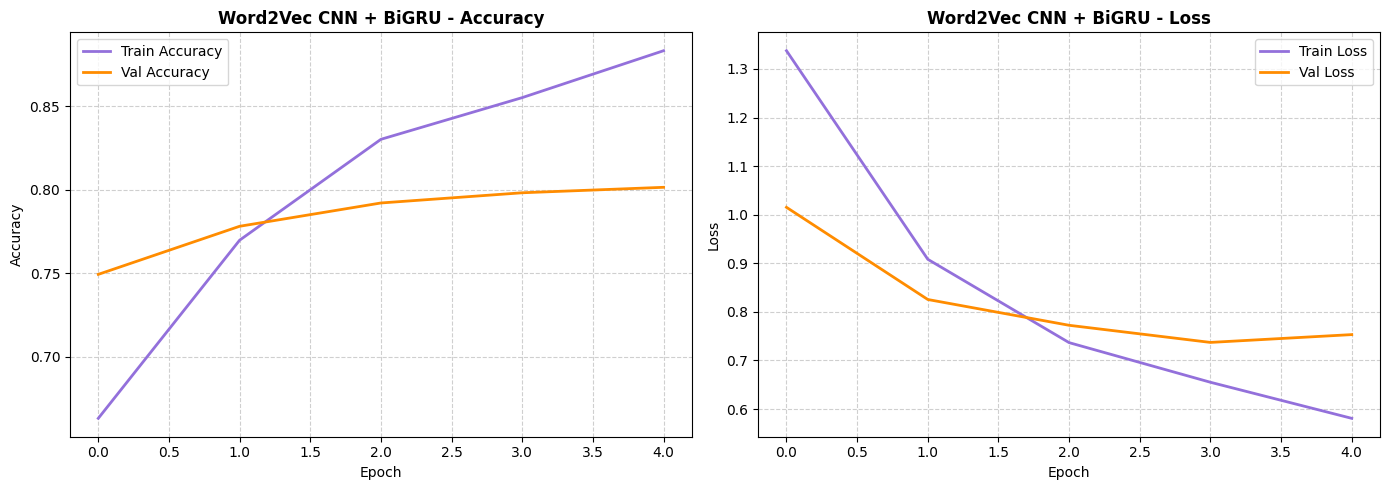

In [27]:
# =========================
# 23. MODEL 3 GRAPHS
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_word2vec.history["accuracy"], label="Train Accuracy", color="mediumpurple", linewidth=2)
axes[0].plot(history_word2vec.history["val_accuracy"], label="Val Accuracy", color="darkorange", linewidth=2)
axes[0].set_title("Word2Vec CNN + BiGRU - Accuracy", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.6)

axes[1].plot(history_word2vec.history["loss"], label="Train Loss", color="mediumpurple", linewidth=2)
axes[1].plot(history_word2vec.history["val_loss"], label="Val Loss", color="darkorange", linewidth=2)
axes[1].set_title("Word2Vec CNN + BiGRU - Loss", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7526 - loss: 1.0140
179/179 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
Word2Vec CNN + BiGRU Test Accuracy: 0.75262051820755
               precision    recall  f1-score   support

Not Sarcastic       0.73      0.85      0.78      2997
    Sarcastic       0.79      0.65      0.71      2727

     accuracy                           0.75      5724
    macro avg       0.76      0.75      0.75      5724
 weighted avg       0.76      0.75      0.75      5724



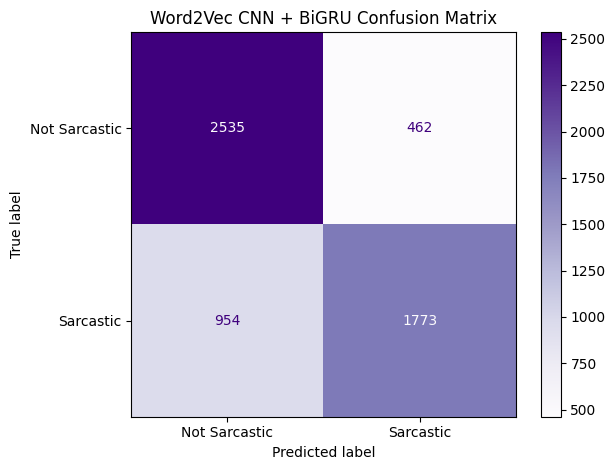

In [28]:
# =========================
# 24. EVALUATE MODEL 3
# =========================

word2vec_loss, word2vec_acc = model_word2vec.evaluate(X_test_pad, y_test)

word2vec_pred_prob = model_word2vec.predict(X_test_pad)
word2vec_pred = (word2vec_pred_prob > 0.5).astype(int).flatten()

print("Word2Vec CNN + BiGRU Test Accuracy:", word2vec_acc)
print(classification_report(y_test, word2vec_pred,
      target_names=["Not Sarcastic", "Sarcastic"], zero_division=0))

cm = confusion_matrix(y_test, word2vec_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Sarcastic", "Sarcastic"])
disp.plot(cmap="Purples")
plt.title("Word2Vec CNN + BiGRU Confusion Matrix")
plt.tight_layout()
plt.show()

In [29]:
# =========================
# 25. FINAL MODEL COMPARISON TABLE
# =========================

results_df = pd.DataFrame({
    "Model": [
        "Stacked GRU",
        "CNN + BiLSTM",
        "Word2Vec CNN + BiGRU"
    ],
    "Accuracy": [
        rnn_acc,
        lstm_acc,
        word2vec_acc
    ],
    "Precision": [
        precision_score(y_test, rnn_pred, zero_division=0),
        precision_score(y_test, lstm_pred, zero_division=0),
        precision_score(y_test, word2vec_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rnn_pred, zero_division=0),
        recall_score(y_test, lstm_pred, zero_division=0),
        recall_score(y_test, word2vec_pred, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, rnn_pred, zero_division=0),
        f1_score(y_test, lstm_pred, zero_division=0),
        f1_score(y_test, word2vec_pred, zero_division=0)
    ],
    "Training Time Seconds": [
        rnn_time,
        lstm_time,
        word2vec_time
    ]
})

print(results_df)

                  Model  Accuracy  Precision    Recall  F1 Score  \
0           Stacked GRU  0.792977   0.760297  0.825816  0.791703   
1          CNN + BiLSTM  0.774808   0.844349  0.646498  0.732295   
2  Word2Vec CNN + BiGRU  0.752621   0.793289  0.650165  0.714631   

   Training Time Seconds  
0             200.466963  
1             104.714322  
2             191.699883  


/tmp/ipykernel_1167/4101841183.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(results_df["Model"], rotation=20, ha="right")


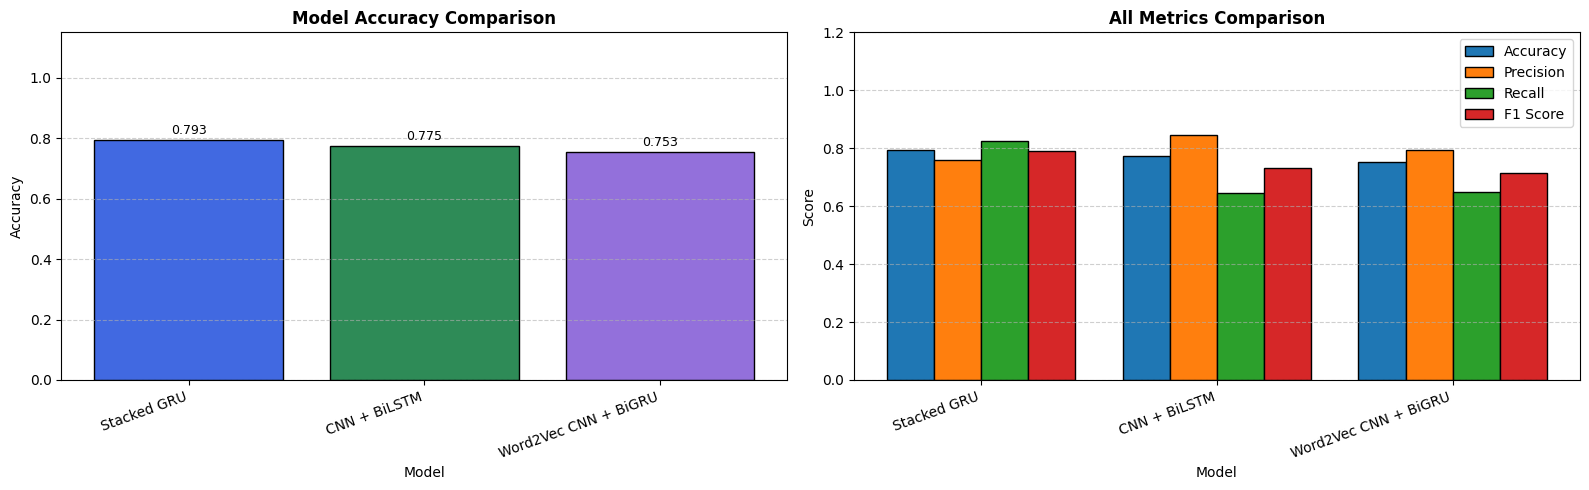

In [30]:
# =========================
# 26. FINAL ACCURACY COMPARISON GRAPH
# =========================

colors = ["royalblue", "seagreen", "mediumpurple"]
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart - accuracy comparison
bars = axes[0].bar(results_df["Model"], results_df["Accuracy"],
                   color=colors, edgecolor="black")
axes[0].set_title("Model Accuracy Comparison", fontweight="bold")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.15)
axes[0].set_xticklabels(results_df["Model"], rotation=20, ha="right")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f"{bar.get_height():.3f}",
                 ha="center", va="bottom", fontsize=9)

# Grouped bar chart - all metrics
x = np.arange(len(results_df["Model"]))
width = 0.2
for i, metric in enumerate(metrics):
    axes[1].bar(x + i * width, results_df[metric], width,
                label=metric, edgecolor="black")

axes[1].set_title("All Metrics Comparison", fontweight="bold")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1.2)
axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(results_df["Model"], rotation=20, ha="right")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [31]:
# =========================
# 27. ERROR ANALYSIS
# =========================

error_df = pd.DataFrame({
    "Original Headline": X_test_text.values,
    "Actual": y_test.values,
    "Predicted": word2vec_pred
})

wrong_predictions = error_df[error_df["Actual"] != error_df["Predicted"]]

print(f"Total Wrong Predictions: {len(wrong_predictions)} out of {len(error_df)}")
wrong_predictions.head(3)

Total Wrong Predictions: 1416 out of 5724


,Original Headline,Actual,Predicted
2,group christie campaign deserter found forest,1,0
3,noose found africanamerican history museum exh...,0,1
4,democratic congressman protest trump environme...,1,0


In [32]:
# =========================
# 28. REAL-TIME PREDICTION FUNCTION
# =========================

def predict_sarcasm(headline):
    cleaned = clean_text(headline)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")

    prediction = model_word2vec.predict(padded_seq)[0][0]

    if prediction >= 0.5:
        return "Sarcastic", round(float(prediction), 4)
    else:
        return "Not Sarcastic", round(float(prediction), 4)


label, confidence = predict_sarcasm("local man finally discovers secret to doing nothing all day")
print(f"Prediction: {label} (confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Prediction: Sarcastic (confidence: 0.8597)


In [33]:
# =========================
# 29. SAVE MODELS
# =========================

model_rnn.save("/content/stacked_gru_sarcasm.h5")
model_lstm.save("/content/cnn_bilstm_sarcasm.h5")
model_word2vec.save("/content/word2vec_cnn_bigru_sarcasm.h5")

print("All 3 models saved successfully.")


All 3 models saved successfully.
